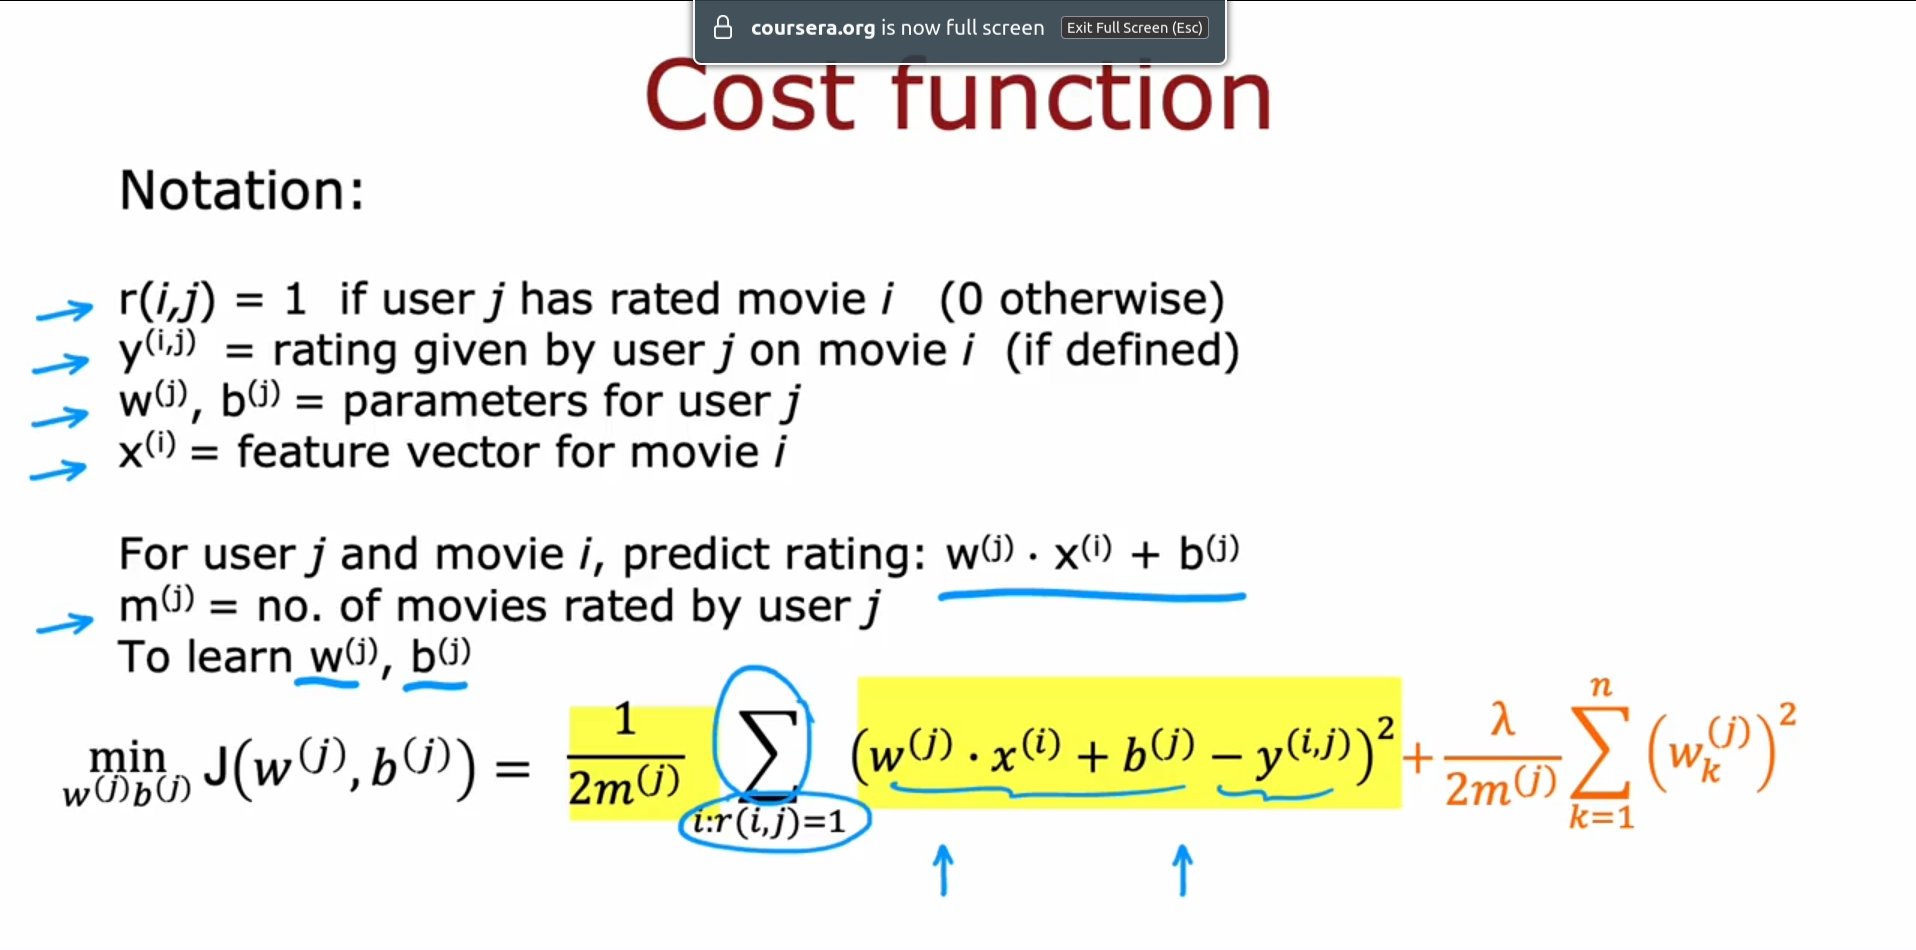

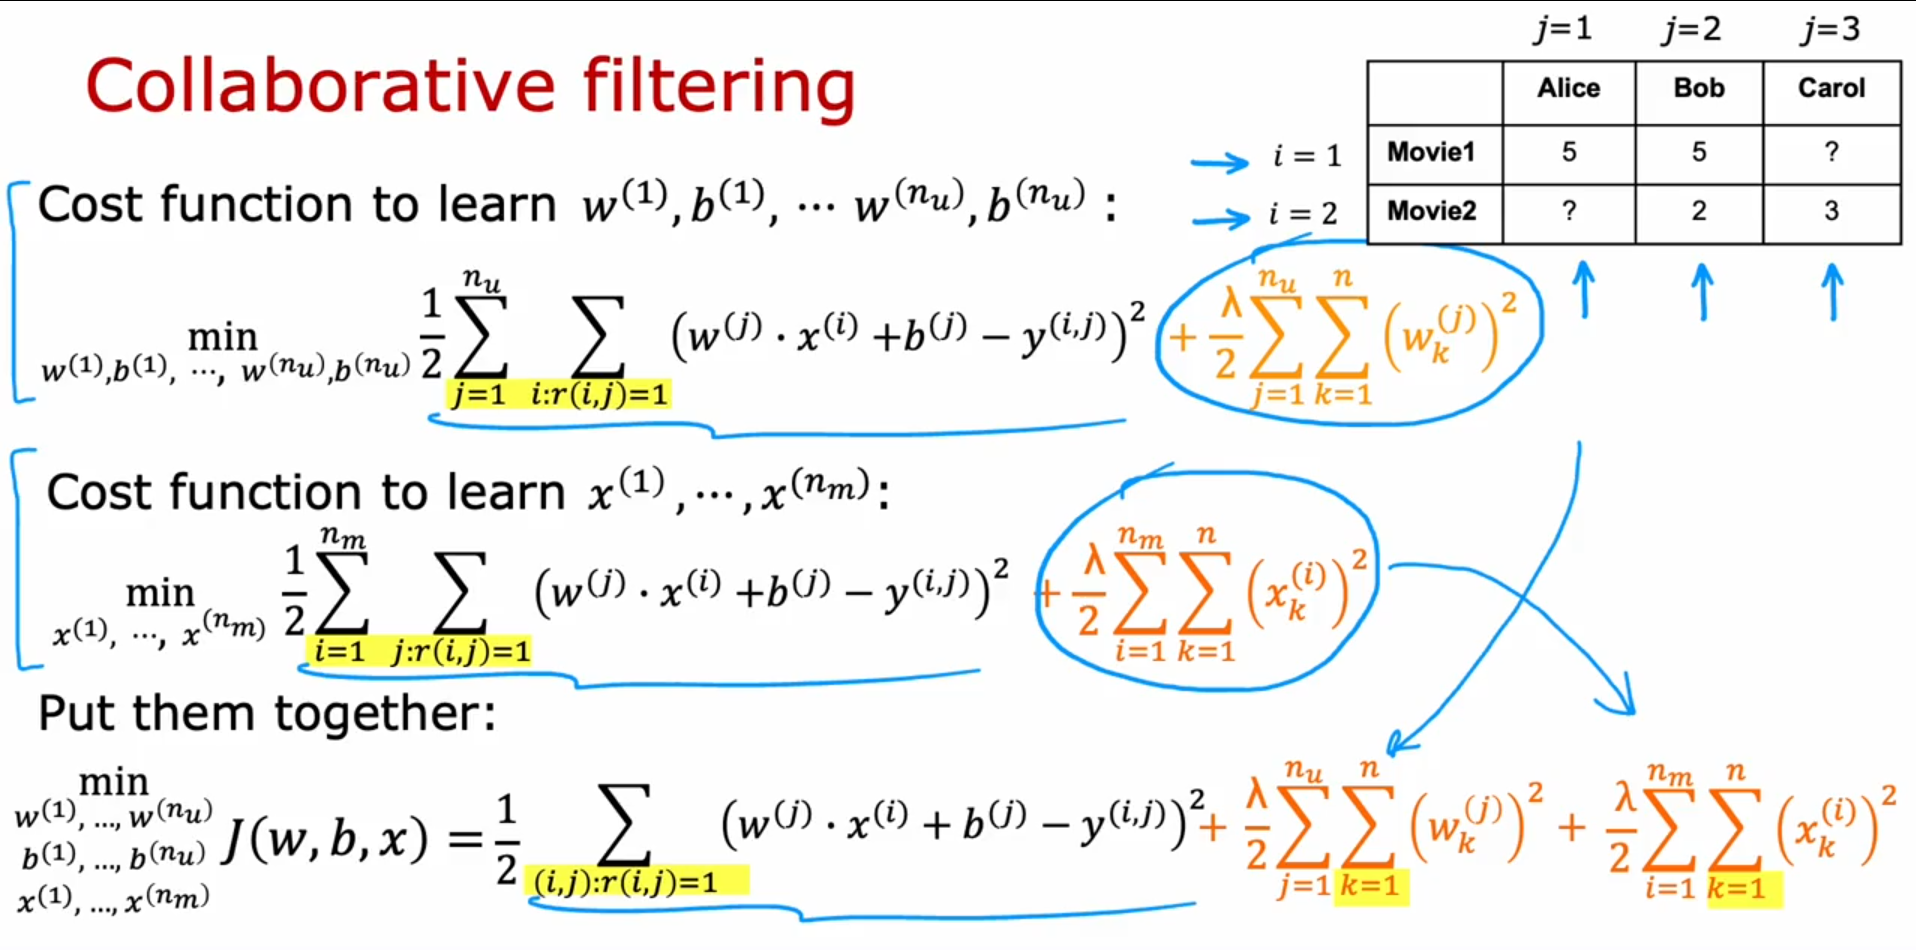

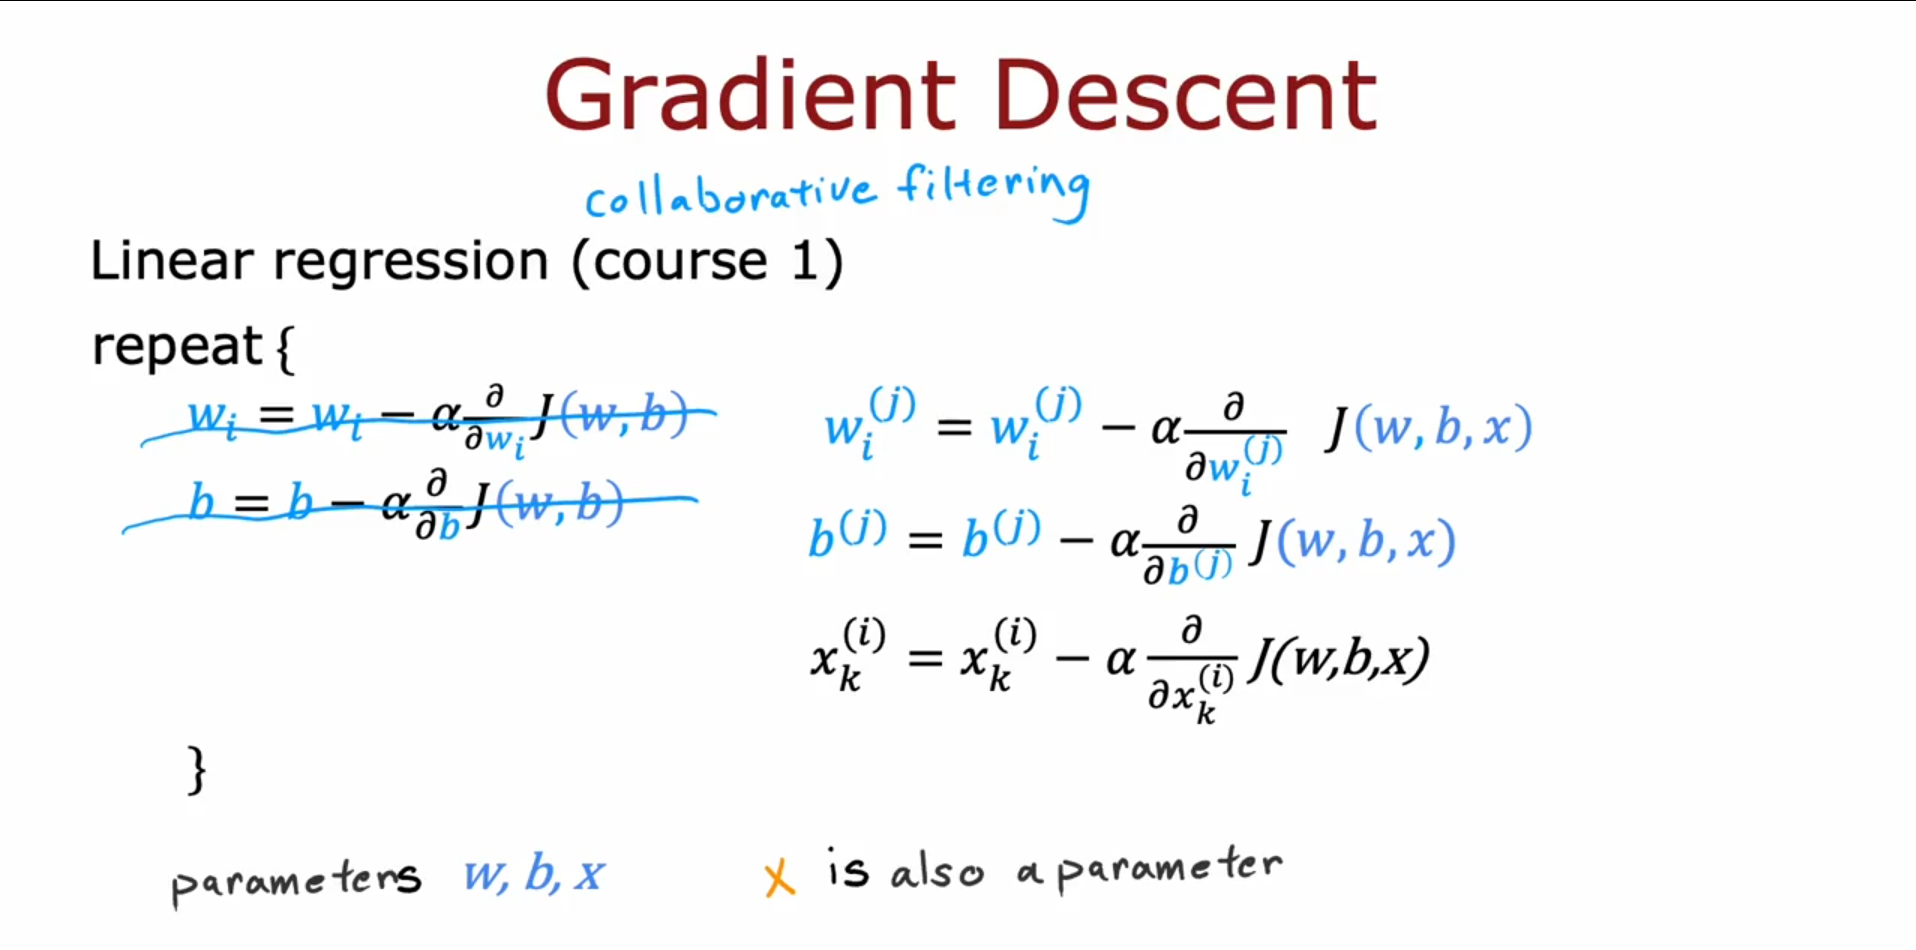

## Two-Tower Model ##

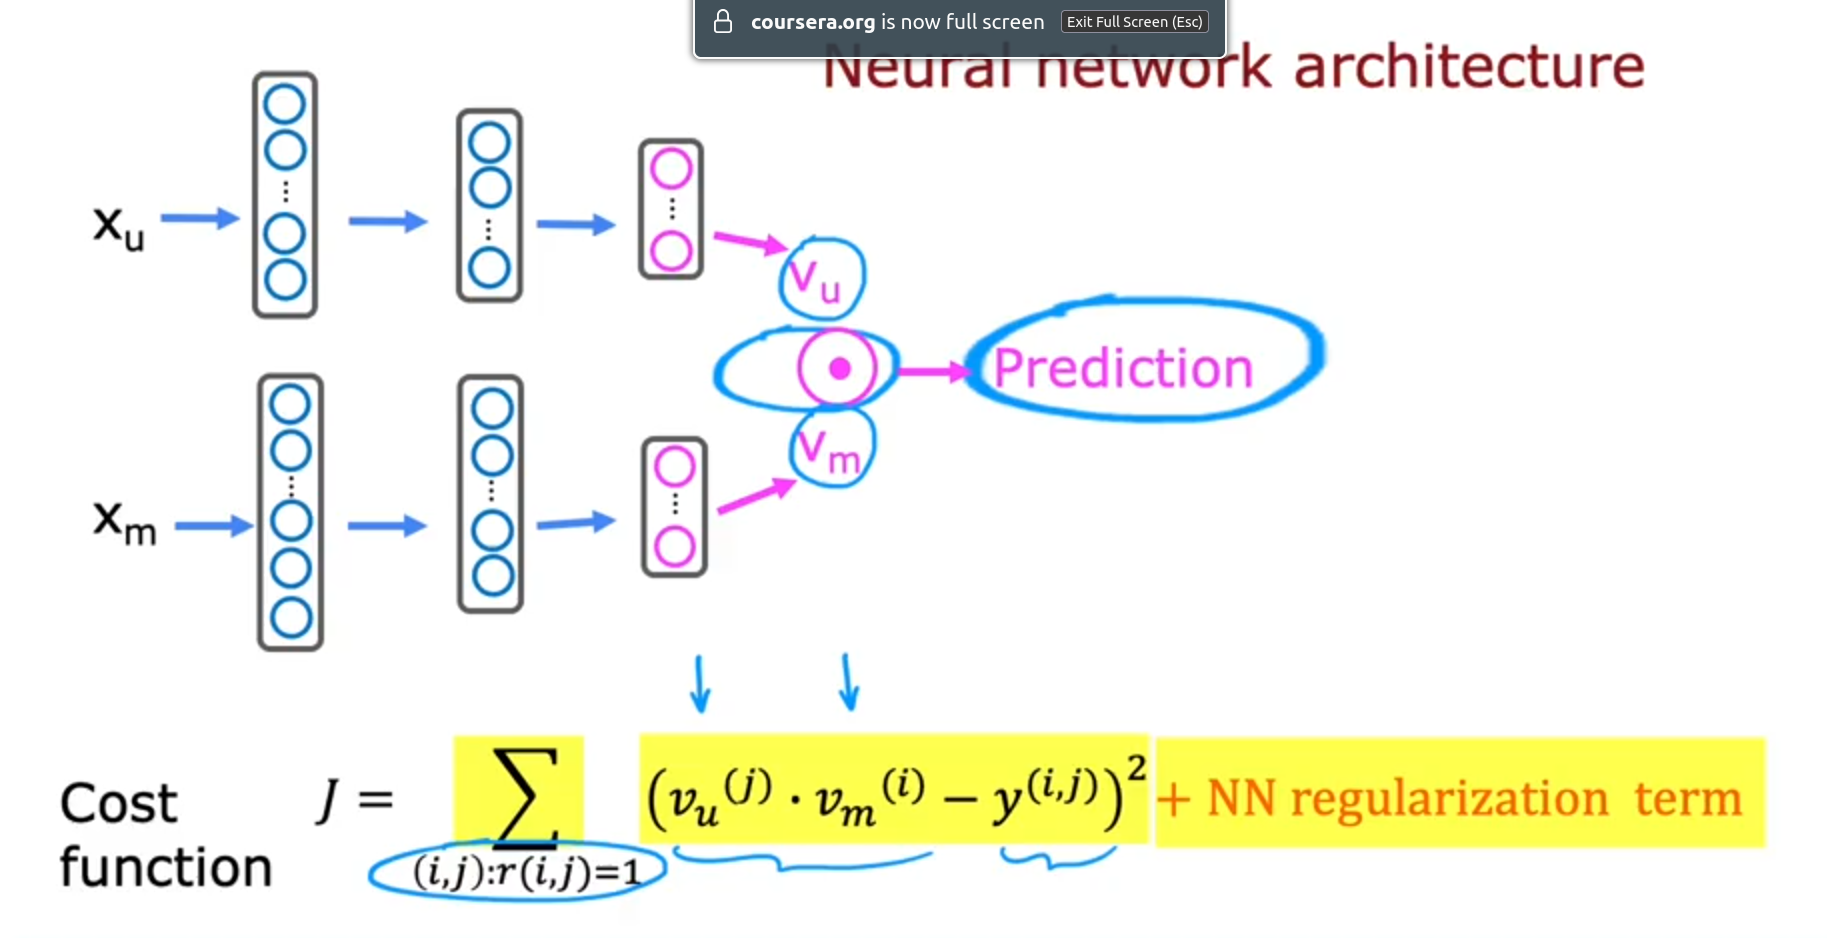

1-)Kullanıcı Kulesi (User Tower): Senin yaşın, cinsiyetin, geçmişte izlediğin filmler, arama geçmişin vb. bir araya gelir ve bir sinir ağından (Dense Layers) geçer. Sonuçta seni temsil eden, örneğin 32 boyutlu bir vektör ($v_u$) çıkar.

2-)Ürün Kulesi (Item Tower): Filmin yılı, yönetmeni, oyuncuları, türü (aksiyon, gerilim) bir araya gelir ve başka bir sinir ağından geçer. Sonuçta o filmi temsil eden, yine 32 boyutlu bir vektör ($v_m$) çıkar.

3-)Çarpışma (Dot Product): Bu iki vektör havada çarpıştırılır (nokta çarpımı yapılır). Vektörler birbirine ne kadar benziyorsa (aynı yöne bakıyorsa), sonuç o kadar büyük çıkar ve sistem "Bu adam bu filmi kesin izler!" der.

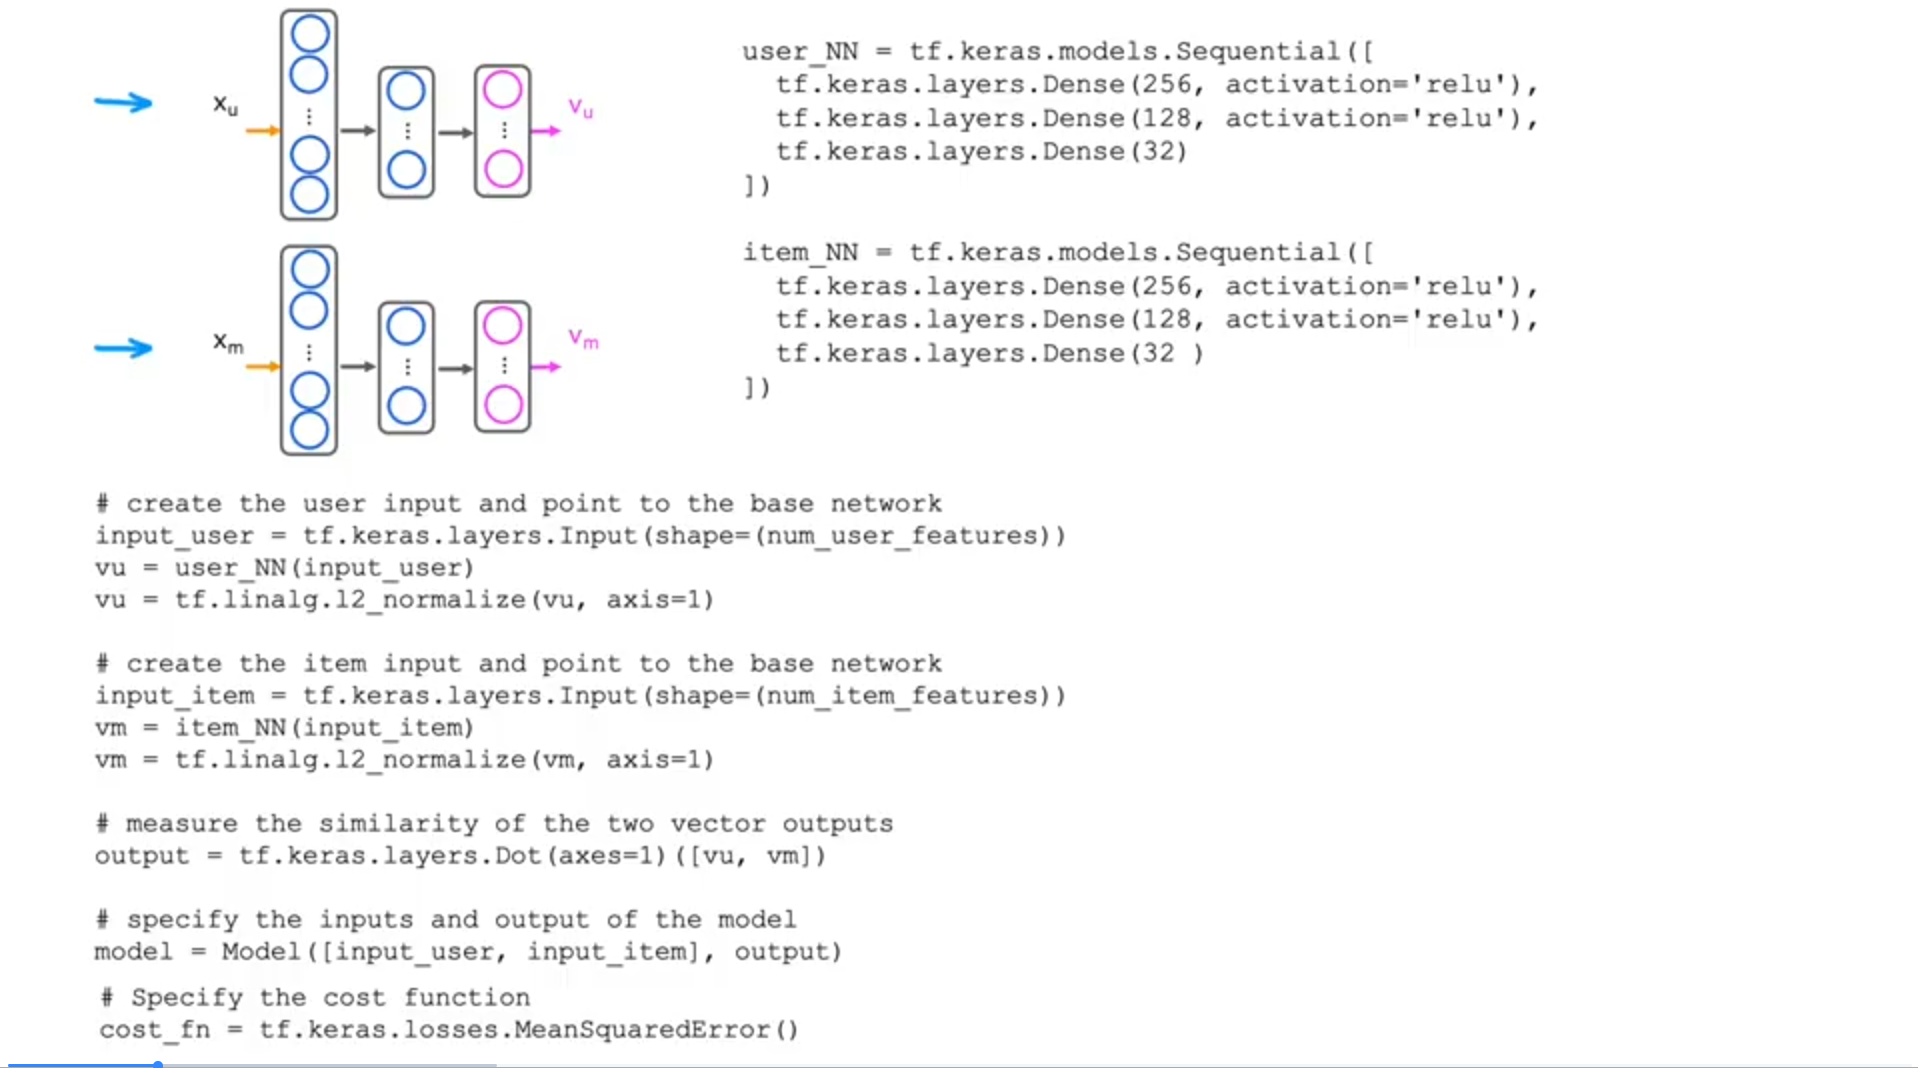

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dot
from tensorflow.keras.losses import MeanSquaredError

# Değişkenleri belirleyelim (Kendi verine göre değiştirebilirsin)
num_user_features = 14 # Kullanıcının özellik sayısı
num_item_features = 20 # Ürünün/Filmin özellik sayısı

# 1. KULLANICI KULESİ (User Network)
user_NN = tf.keras.models.Sequential([
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(32) # Son katmanda aktivasyon yok (linear), çünkü normalize edeceğiz
])

# 2. ÜRÜN KULESİ (Item Network)
item_NN = tf.keras.models.Sequential([
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(32)
])

# ---- SİSTEMİ BİRLEŞTİRME (FÜZYON) ----

# Kullanıcı girdisini al, ağdan geçir ve L2 Normalize et (Uzunluğu 1 yap)
input_user = Input(shape=(num_user_features,))
vu = user_NN(input_user)
vu = tf.linalg.l2_normalize(vu, axis=1)

# Ürün girdisini al, ağdan geçir ve L2 Normalize et
input_item = Input(shape=(num_item_features,))
vm = item_NN(input_item)
vm = tf.linalg.l2_normalize(vm, axis=1)

# İki normalize vektörün Kosinüs Benzerliğini (Nokta Çarpımı) al
output = Dot(axes=1)([vu, vm])

# Modeli paketle (Girdiler -> Çıktı)
model = Model(inputs=[input_user, input_item], outputs=output)

# Eğitim için modeli derle
cost_fn = MeanSquaredError()
model.compile(optimizer='adam', loss=cost_fn)

# Modelin özetini (mimarinin haritasını) görmek istersen:
model.summary()

2026-05-09 13:06:29.556983: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 13:06:29.883047: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 13:06:31.372748: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 13:06:34.361424: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:

ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.ops`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```
